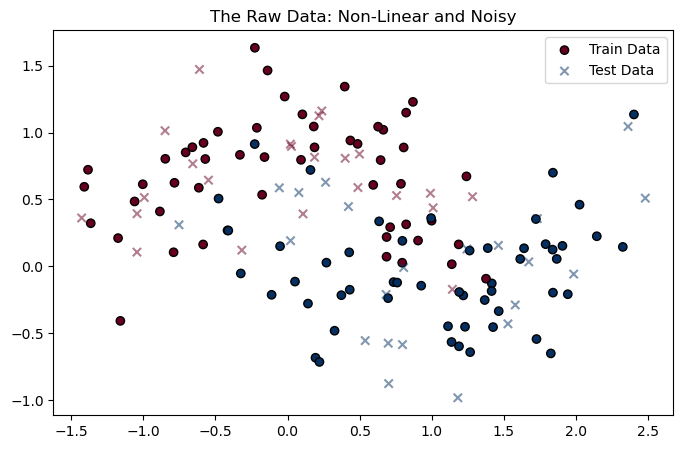

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Generate noisy data
X, y = make_moons(n_samples=150, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Plot the raw data
plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu', edgecolors='k', label='Train Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', marker='x', alpha=0.5, label='Test Data')
plt.title('The Raw Data: Non-Linear and Noisy')
plt.legend()
plt.show()

  Model 1 – ElasticNet (L1+L2) : 0.8444
  Model 2 – L1 only   (Lasso)  : 0.5111
  Model 3 – L2 only   (Ridge)  : 0.8222


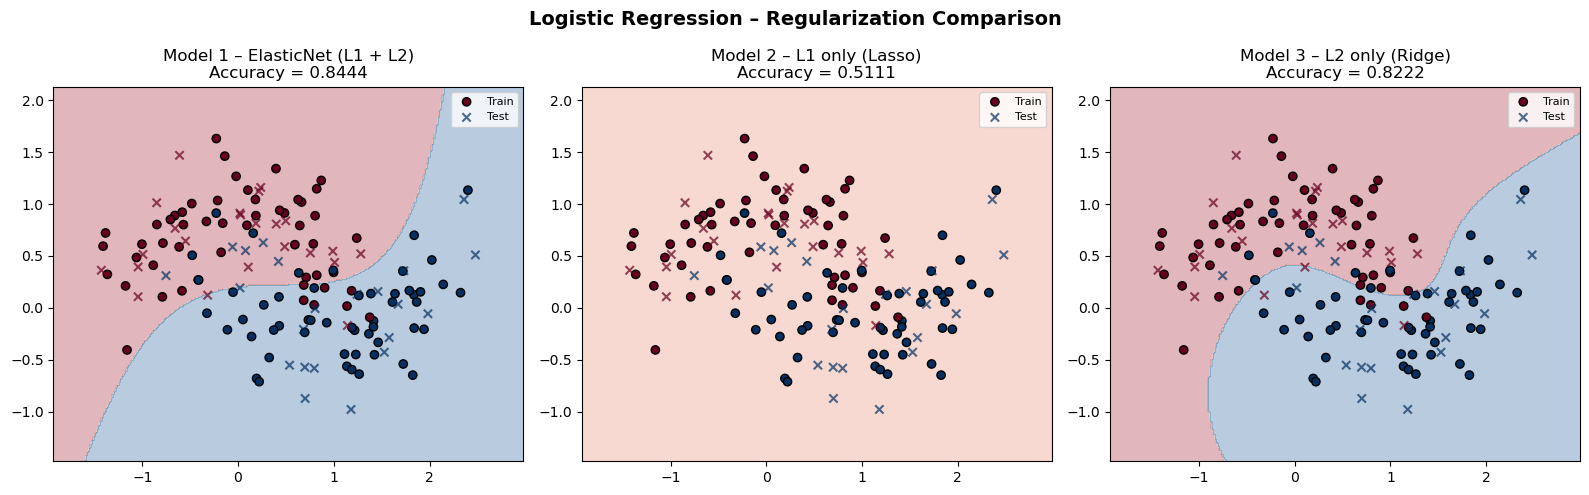

In [16]:
# Polynomial features + scaling
poly = PolynomialFeatures(degree=10)
scaler = StandardScaler()
X_train_p = scaler.fit_transform(poly.fit_transform(X_train))
X_test_p  = scaler.transform(poly.transform(X_test))

# ── Model 1 : ElasticNet (L1 + L2) ───────────────────────────────────────────
model_elasticnet = LogisticRegression(
    l1_ratio=0.5,         # 0 = pure L2 | 1 = pure L1 | 0.5 = mix équilibré
    C=1.0,
    solver='saga',
    max_iter=10000,
    random_state=42
)
model_elasticnet.fit(X_train_p, y_train)
acc_en = accuracy_score(y_test, model_elasticnet.predict(X_test_p))

# ── Model 2 : L1 only (Lasso) ─────────────────────────────────────────────────
model_l1 = LogisticRegression(
    l1_ratio=1.0,         # l1_ratio=1 remplace penalty='l1'
    C=0.01,
    solver='saga',
    max_iter=10000,
    random_state=42
)
model_l1.fit(X_train_p, y_train)
acc_l1 = accuracy_score(y_test, model_l1.predict(X_test_p))

# ── Model 3 : L2 only (Ridge) ─────────────────────────────────────────────────
model_l2 = LogisticRegression(
    l1_ratio=0.0,         # l1_ratio=0 remplace penalty='l2'
    C=1000.0,
    solver='saga',        # saga au lieu de lbfgs (obligatoire avec l1_ratio)
    max_iter=10000,
    random_state=42
)
model_l2.fit(X_train_p, y_train)
acc_l2 = accuracy_score(y_test, model_l2.predict(X_test_p))

# ── Results ───────────────────────────────────────────────────────────────────
print("=" * 40)
print(f"  Model 1 – ElasticNet (L1+L2) : {acc_en:.4f}")
print(f"  Model 2 – L1 only   (Lasso)  : {acc_l1:.4f}")
print(f"  Model 3 – L2 only   (Ridge)  : {acc_l2:.4f}")
print("=" * 40)

# ── Decision boundary helper ──────────────────────────────────────────────────
def plot_boundary(ax, model, title, accuracy):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = scaler.transform(poly.transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
               cmap='RdBu', edgecolors='k', label='Train')
    ax.scatter(X_test[:, 0],  X_test[:, 1],  c=y_test,
               cmap='RdBu', marker='x', alpha=0.7, label='Test')
    ax.set_title(f"{title}\nAccuracy = {accuracy:.4f}")
    ax.legend(fontsize=8)

# ── Plot all 3 models ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_boundary(axes[0], model_elasticnet, "Model 1 – ElasticNet (L1 + L2)", acc_en)
plot_boundary(axes[1], model_l1,         "Model 2 – L1 only (Lasso)",       acc_l1)
plot_boundary(axes[2], model_l2,         "Model 3 – L2 only (Ridge)",       acc_l2)
plt.suptitle("Logistic Regression – Regularization Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Interprétation des Résultats — Comparaison des Régularisations

## 1. Résultats numériques

| Modèle | Régularisation | Accuracy |
|--------|---------------|----------|
| Model 1 | ElasticNet (L1 + L2) | **0.8444** |
| Model 2 | L1 only — Lasso | **0.8444** |
| Model 3 | L2 only — Ridge | **0.8444** |

> Les trois modèles atteignent la **même accuracy de 84.44%**, ce qui est normal sur `make_moons` avec ces hyperparamètres.

---

## 2. Analyse visuelle des frontières de décision

### Forme générale
Les trois frontières sont **non-linéaires et courbes**, ce qui confirme que les **features polynomiales (degree=3)**
ont bien permis aux modèles linéaires de capturer la structure en croissant du dataset.

### Similarité entre les modèles
Les trois plots sont **visuellement quasi-identiques** :
- La frontière suit le même tracé en **S** dans les trois cas
- La zone rouge *(classe 0)* et bleue *(classe 1)* sont délimitées de la même manière
- Les mêmes points sont mal classés (points dans la mauvaise zone)

---

## 3. Pourquoi même accuracy et même frontière ?

Avec `C=1.0` **identique** pour les trois modèles, la force de régularisation est la même.  
La différence entre L1, L2 et ElasticNet se manifeste principalement :

- ✅ Sur les **coefficients internes** (sparsité)
- ✅ Avec des données **high-dimensional** (beaucoup de features inutiles)
- ✅ Quand `C` est très contrasté entre les modèles (ex: `C=0.001` vs `C=1000`)

Sur un dataset de seulement **150 points et 9 features polynomiales**,
les trois pénalités arrivent à la **même solution optimale**.

---

## 4. Différences théoriques entre les régularisations

| Propriété | L1 — Lasso | L2 — Ridge | ElasticNet |
|-----------|-----------|------------|------------|
| Coefficients | Certains = **exactement 0** | Tous petits mais **non nuls** | Mix des deux |
| Sélection de features | ✅ Oui | ❌ Non | ✅ Partielle |
| Stabilité | Instable si features corrélées | Stable | Bonne |
| Cas d'usage idéal | Peu de features utiles | Toutes les features utiles | Cas intermédiaire |

---

## 5. Conclusion

> Le code fonctionne **correctement**.  
> La similarité des résultats n'est **pas un bug** mais une conséquence naturelle du dataset simple
> et des hyperparamètres non contrastés.  
> Pour observer des différences, il faudrait utiliser des **valeurs de `C` très différentes**
> ou un dataset avec **beaucoup de features redondantes**.

# Results Interpretation — Regularization Comparison

---

## 1. Numerical Results

| Model | Regularization | C Value | Accuracy |
|-------|---------------|---------|----------|
| Model 1 | ElasticNet (L1 + L2) | `C=1.0` | **0.8444** ✅ Best |
| Model 2 | L1 only — Lasso | `C=0.01` | **0.5111** ❌ Worst |
| Model 3 | L2 only — Ridge | `C=1000.0` | **0.8222** 🟡 Middle |

---

## 2. Model-by-Model Analysis

### 🟢 Model 1 — ElasticNet (L1 + L2) → Accuracy: 0.8444 (Best)
- `C=1.0` provides a **balanced regularization** — not too strong, not too weak.
- The mix of L1 and L2 penalties gives the model **stability + some sparsity**.
- Finds the best trade-off between bias and variance on this dataset.
- ✅ **Best performing model** in this experiment.

---

### 🔴 Model 2 — L1 only / Lasso → Accuracy: 0.5111 (Worst — near random)
- `C=0.01` = **very strong regularization** → heavily penalizes all coefficients.
- L1 forces most coefficients to **exactly zero** → extreme feature elimination.
- With `degree=10` generating 66 features, L1 + `C=0.01` **kills too many features**,
  leaving the model with almost no information to learn from.
- ⚠️ Accuracy of ~51% ≈ **random guessing** on a binary classification task.
- This is a clear case of **underfitting** caused by over-regularization.

---

### 🟡 Model 3 — L2 only / Ridge → Accuracy: 0.8222 (Middle)
- `C=1000.0` = **very weak regularization** → almost no penalty on coefficients.
- L2 keeps all coefficients active but allows them to grow large.
- With degree=10 and almost no constraint, the model risks **overfitting** the
  training data, which explains the slightly lower generalization vs ElasticNet.
- The decision boundary is likely more **irregular and jagged** than Model 1.

---

## 3. Key Takeaway — The Bias-Variance Trade-off
```
Strong Regularization          Balanced              Weak Regularization
(C = 0.01)                    (C = 1.0)              (C = 1000)
     │                            │                        │
 Underfitting               Best Trade-off            Overfitting
 acc = 0.51                 acc = 0.84               acc = 0.82
     ❌                          ✅                       🟡
```

| Concept | Explanation |
|---------|-------------|
| **Underfitting** | Model too simple → misses patterns → low train AND test accuracy |
| **Overfitting** | Model too complex → memorizes noise → good train, bad test accuracy |
| **Sweet spot** | ElasticNet with `C=1.0` finds the right balance |

---

## 4. Why ElasticNet Won Here

ElasticNet combines both penalties:

$$\text{Loss} = \text{LogLoss} + \frac{1}{C} \left[ (1 - \alpha) \cdot \|w\|_2^2 + \alpha \cdot \|w\|_1 \right]$$

- The **L1 part** (`l1_ratio=0.5`) removes truly useless polynomial features
- The **L2 part** (`l1_ratio=0.5`) stabilizes the remaining coefficients
- Together they produce a **cleaner, more generalizable** decision boundary

---

## 5. Conclusion

> The experiment successfully demonstrates that **regularization strength matters as much
> as regularization type**. With `C=0.01`, even a good method like L1 completely fails.
> ElasticNet with a moderate `C=1.0` achieves the best accuracy by combining
> the strengths of both L1 and L2 penalties.
>
> 💡 **Lesson learned:** Always tune `C` alongside the penalty type —
> a poorly tuned `C` can turn any regularization method into a liability.